# 02 — Exploratory Data Analysis: Univariate
Distributions of every feature individually, outlier detection, and subscription rates by category.

In [6]:
import sys, warnings
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.config import RAW_DIR, CSV_SEP, TARGET_COL
from src.data_loader import load_dataset
from src.features import encode_target, add_features

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

df_raw = load_dataset(RAW_DIR / "bank-additional-full.csv")
df = encode_target(df_raw.copy(), TARGET_COL)
df = add_features(df)

NUMERIC_COLS = df.select_dtypes("number").columns.drop(TARGET_COL).tolist()
CATEGORICAL_COLS = df_raw.select_dtypes("object").columns.drop(TARGET_COL).tolist()

print(f"Dataset: {df.shape}  |  Numeric: {len(NUMERIC_COLS)}  |  Categorical: {len(CATEGORICAL_COLS)}")

2026-05-17 03:41:46 | INFO     | src.data_loader | Loaded bank-additional-full.csv — shape (41188, 21)
2026-05-17 03:41:46 | INFO     | src.features | Encoded target 'y' → 0/1 (41188 rows).
2026-05-17 03:41:46 | INFO     | src.features | add_features: added 9 engineered features.


Dataset: (41188, 30)  |  Numeric: 17  |  Categorical: 10


## 1 — Numeric Feature Distributions

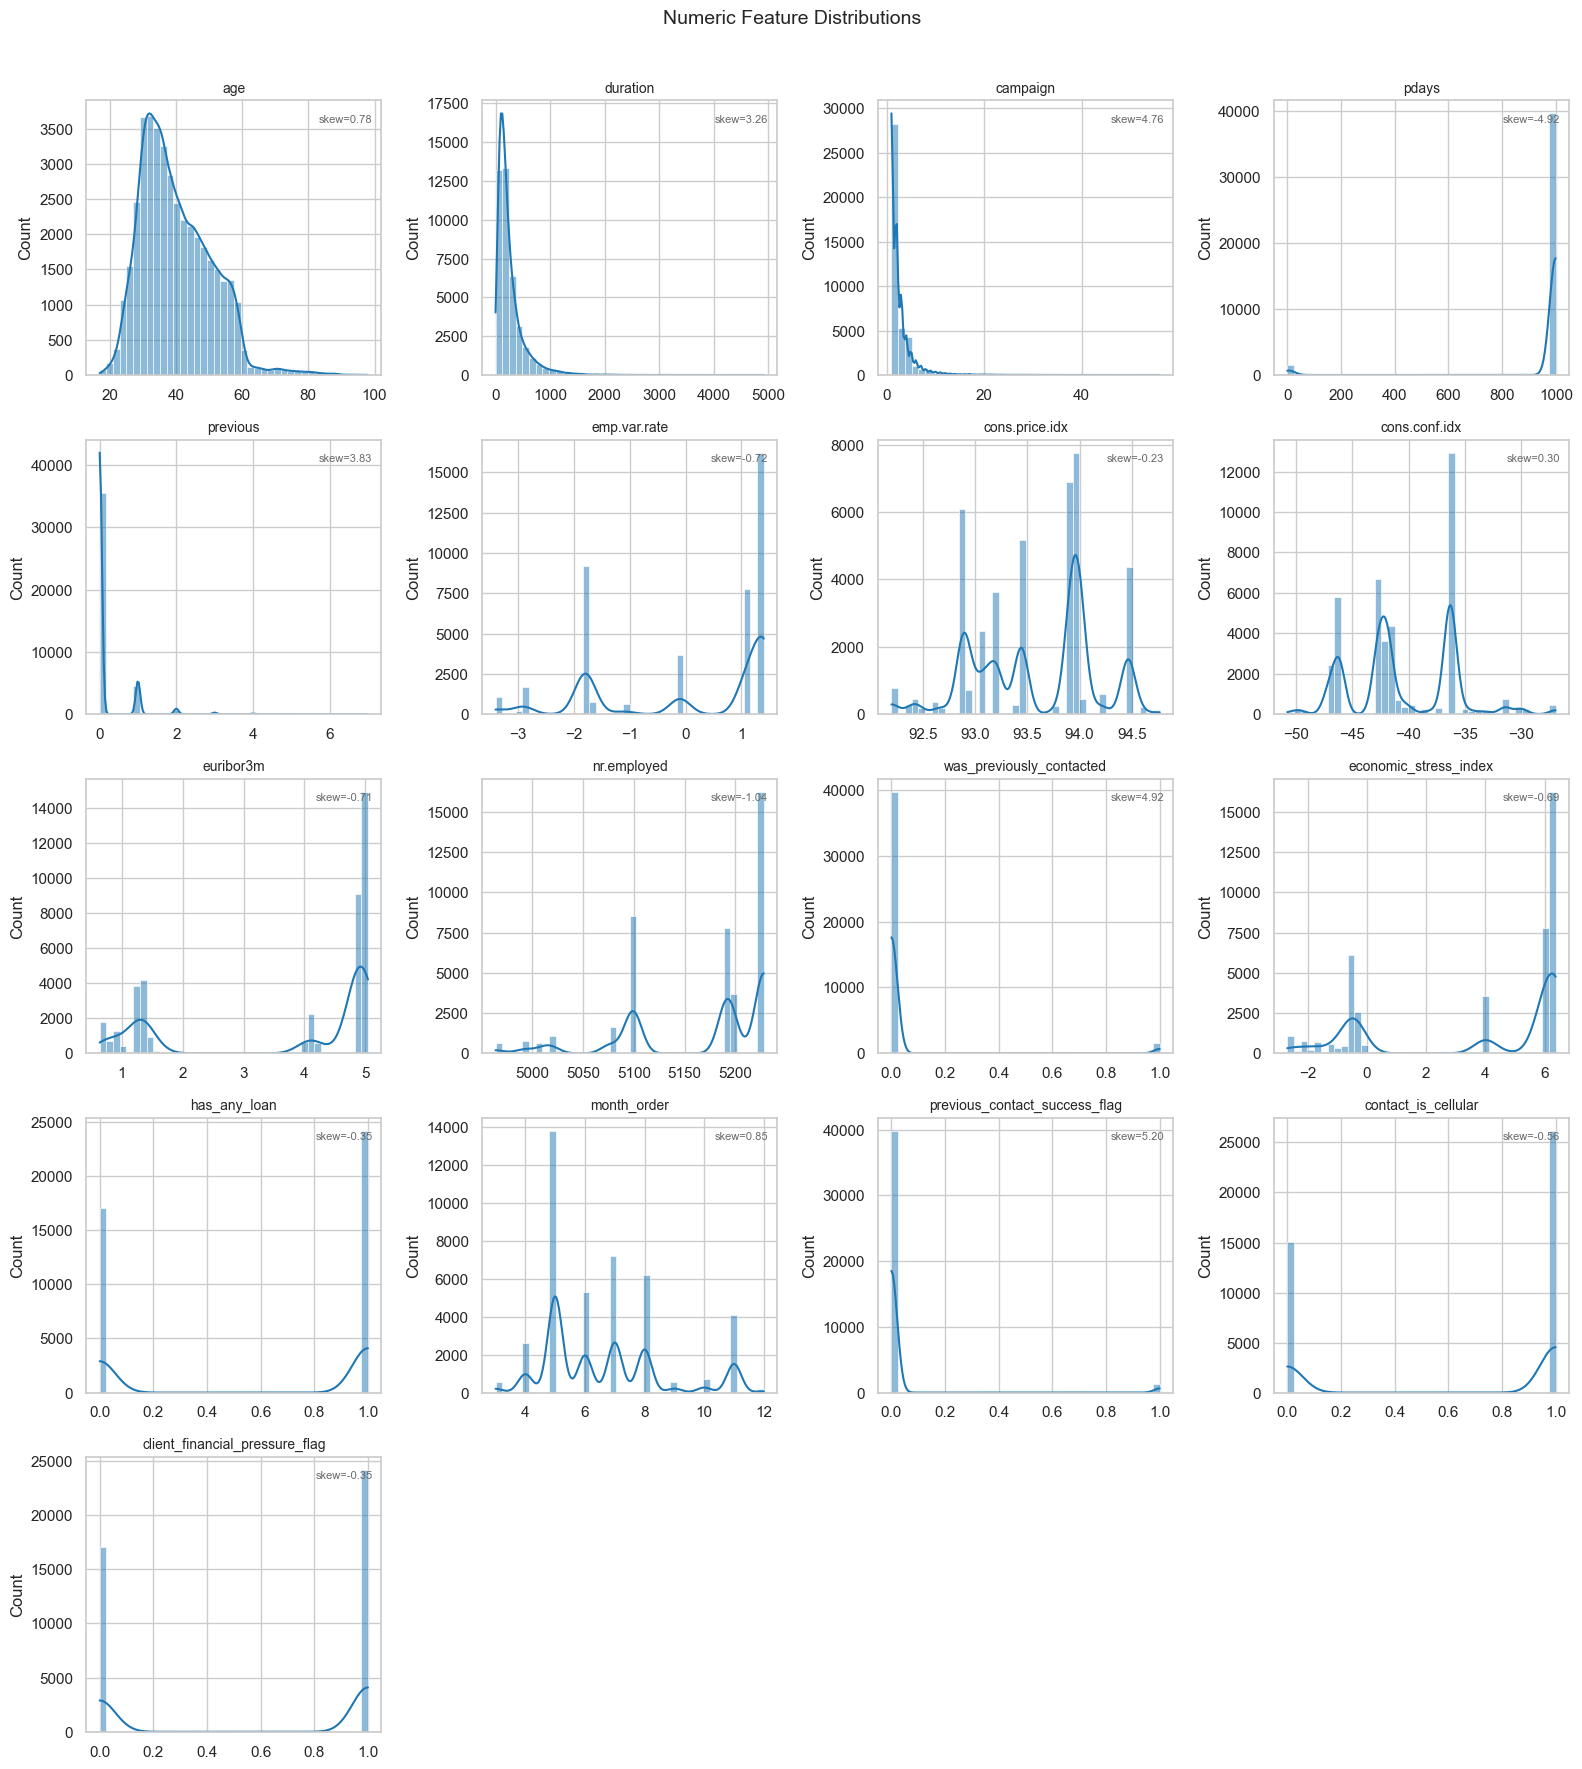

In [7]:
n_cols = 4
n_rows = (len(NUMERIC_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color="#1f77b4", bins=40)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    skew = df[col].skew()
    ax.annotate(f"skew={skew:.2f}", xy=(0.97, 0.95), xycoords="axes fraction",
                ha="right", va="top", fontsize=8, color="dimgray")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2 — Outlier Detection (Box Plots & Z-Scores)

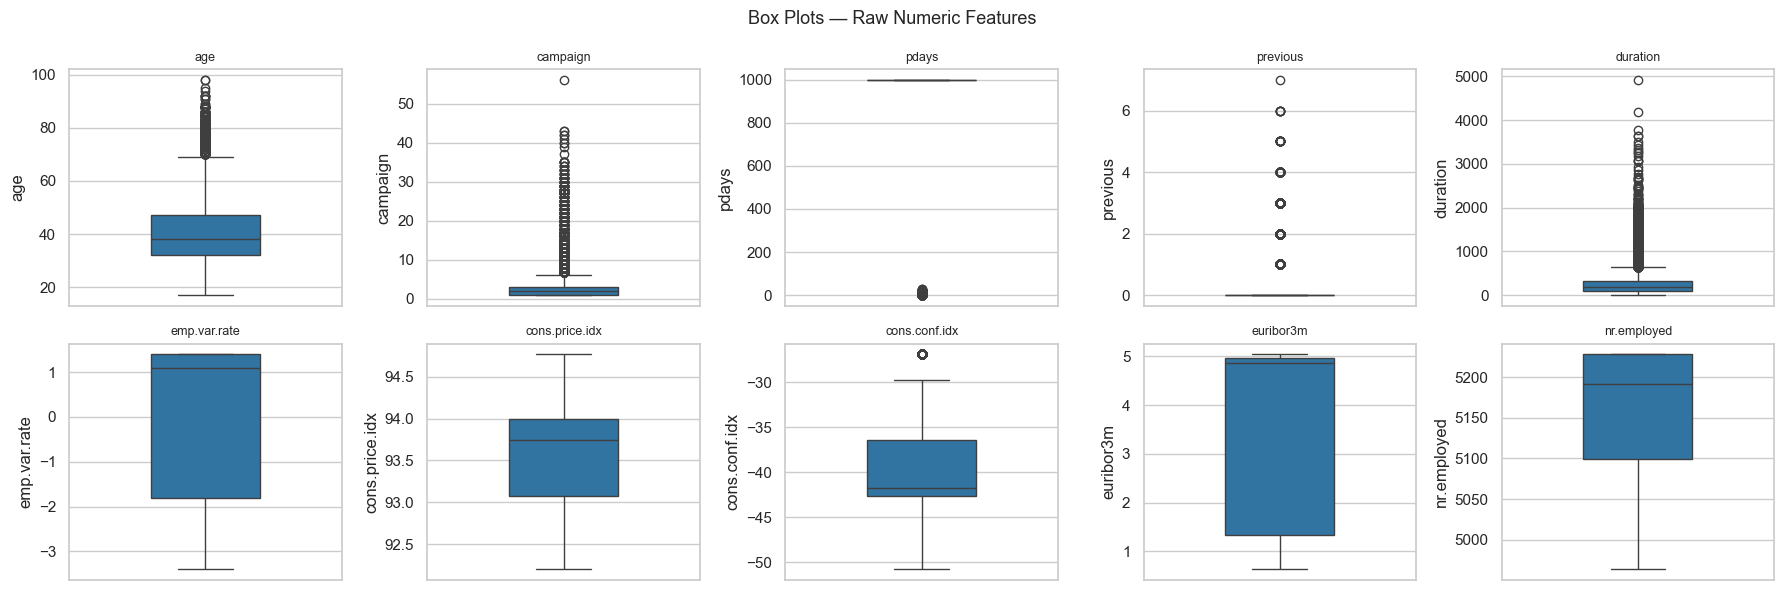

,outliers |z|>3
pdays,1515
previous,1064
campaign,869
duration,861
age,369
emp.var.rate,0
cons.price.idx,0
cons.conf.idx,0
euribor3m,0
nr.employed,0


In [8]:
raw_num = ["age", "campaign", "pdays", "previous", "duration",
           "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
raw_num = [c for c in raw_num if c in df.columns]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, col in zip(axes.flatten(), raw_num):
    sns.boxplot(y=df[col], ax=ax, color="#1f77b4", width=0.4)
    ax.set_title(col, fontsize=9)
plt.suptitle("Box Plots — Raw Numeric Features", fontsize=13)
plt.tight_layout()
plt.show()

# Z-score outlier counts (|z| > 3)
z_table = {}
for col in raw_num:
    z = np.abs(stats.zscore(df[col].dropna()))
    z_table[col] = (z > 3).sum()

outlier_df = pd.Series(z_table, name="outliers |z|>3").sort_values(ascending=False)
display(outlier_df.to_frame())

## 3 — Categorical Feature Value Counts

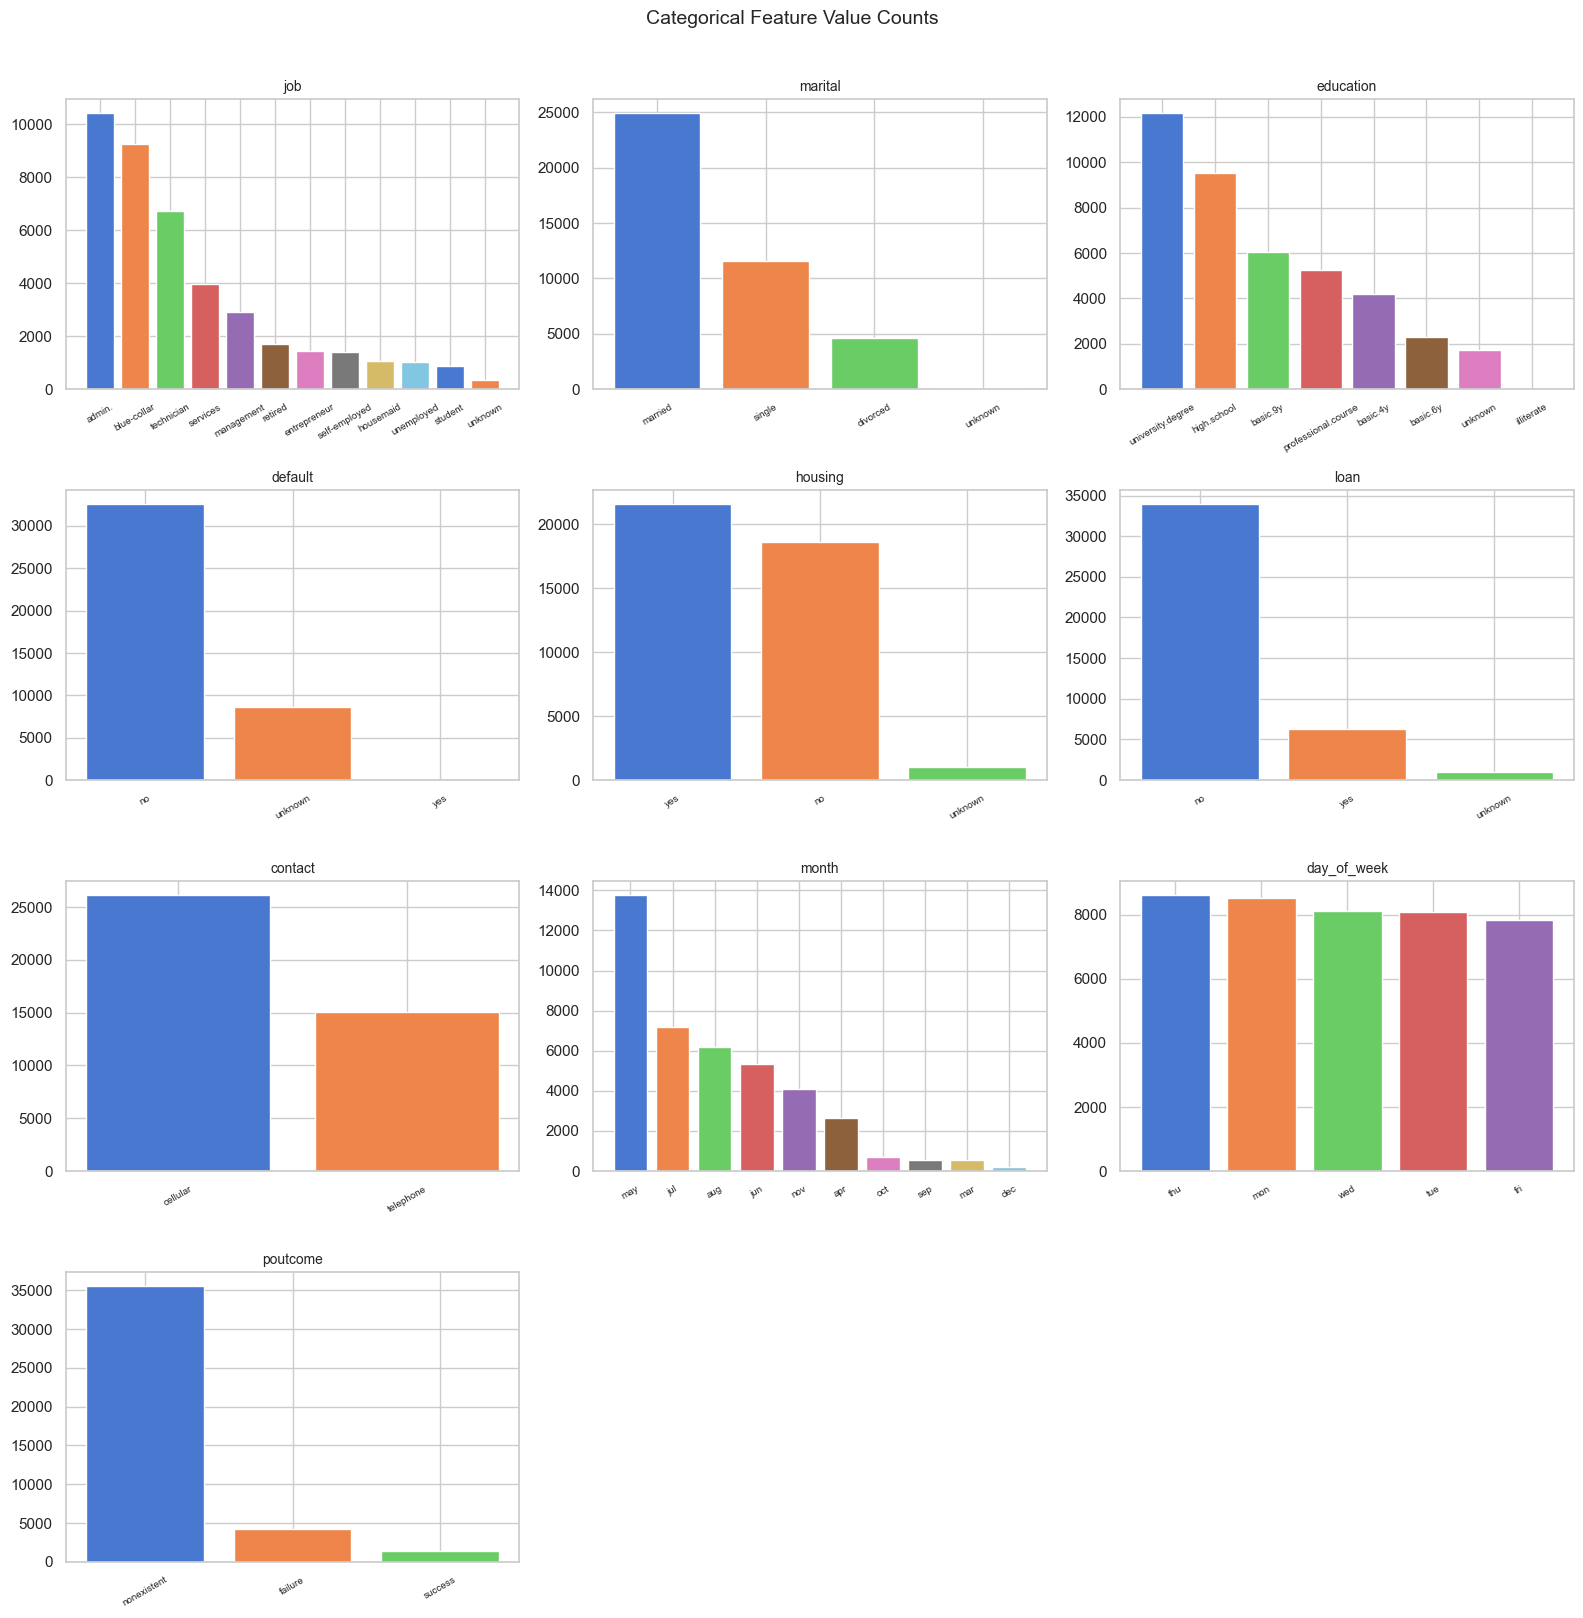

In [9]:
n_cols = 3
n_rows = (len(CATEGORICAL_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    vc = df_raw[col].value_counts()
    axes[i].bar(vc.index, vc.values, color=sns.color_palette("muted", len(vc)))
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis="x", rotation=30, labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Feature Value Counts", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4 — Subscription Rate by Categorical Feature
For each categorical feature, what proportion of each category subscribed?

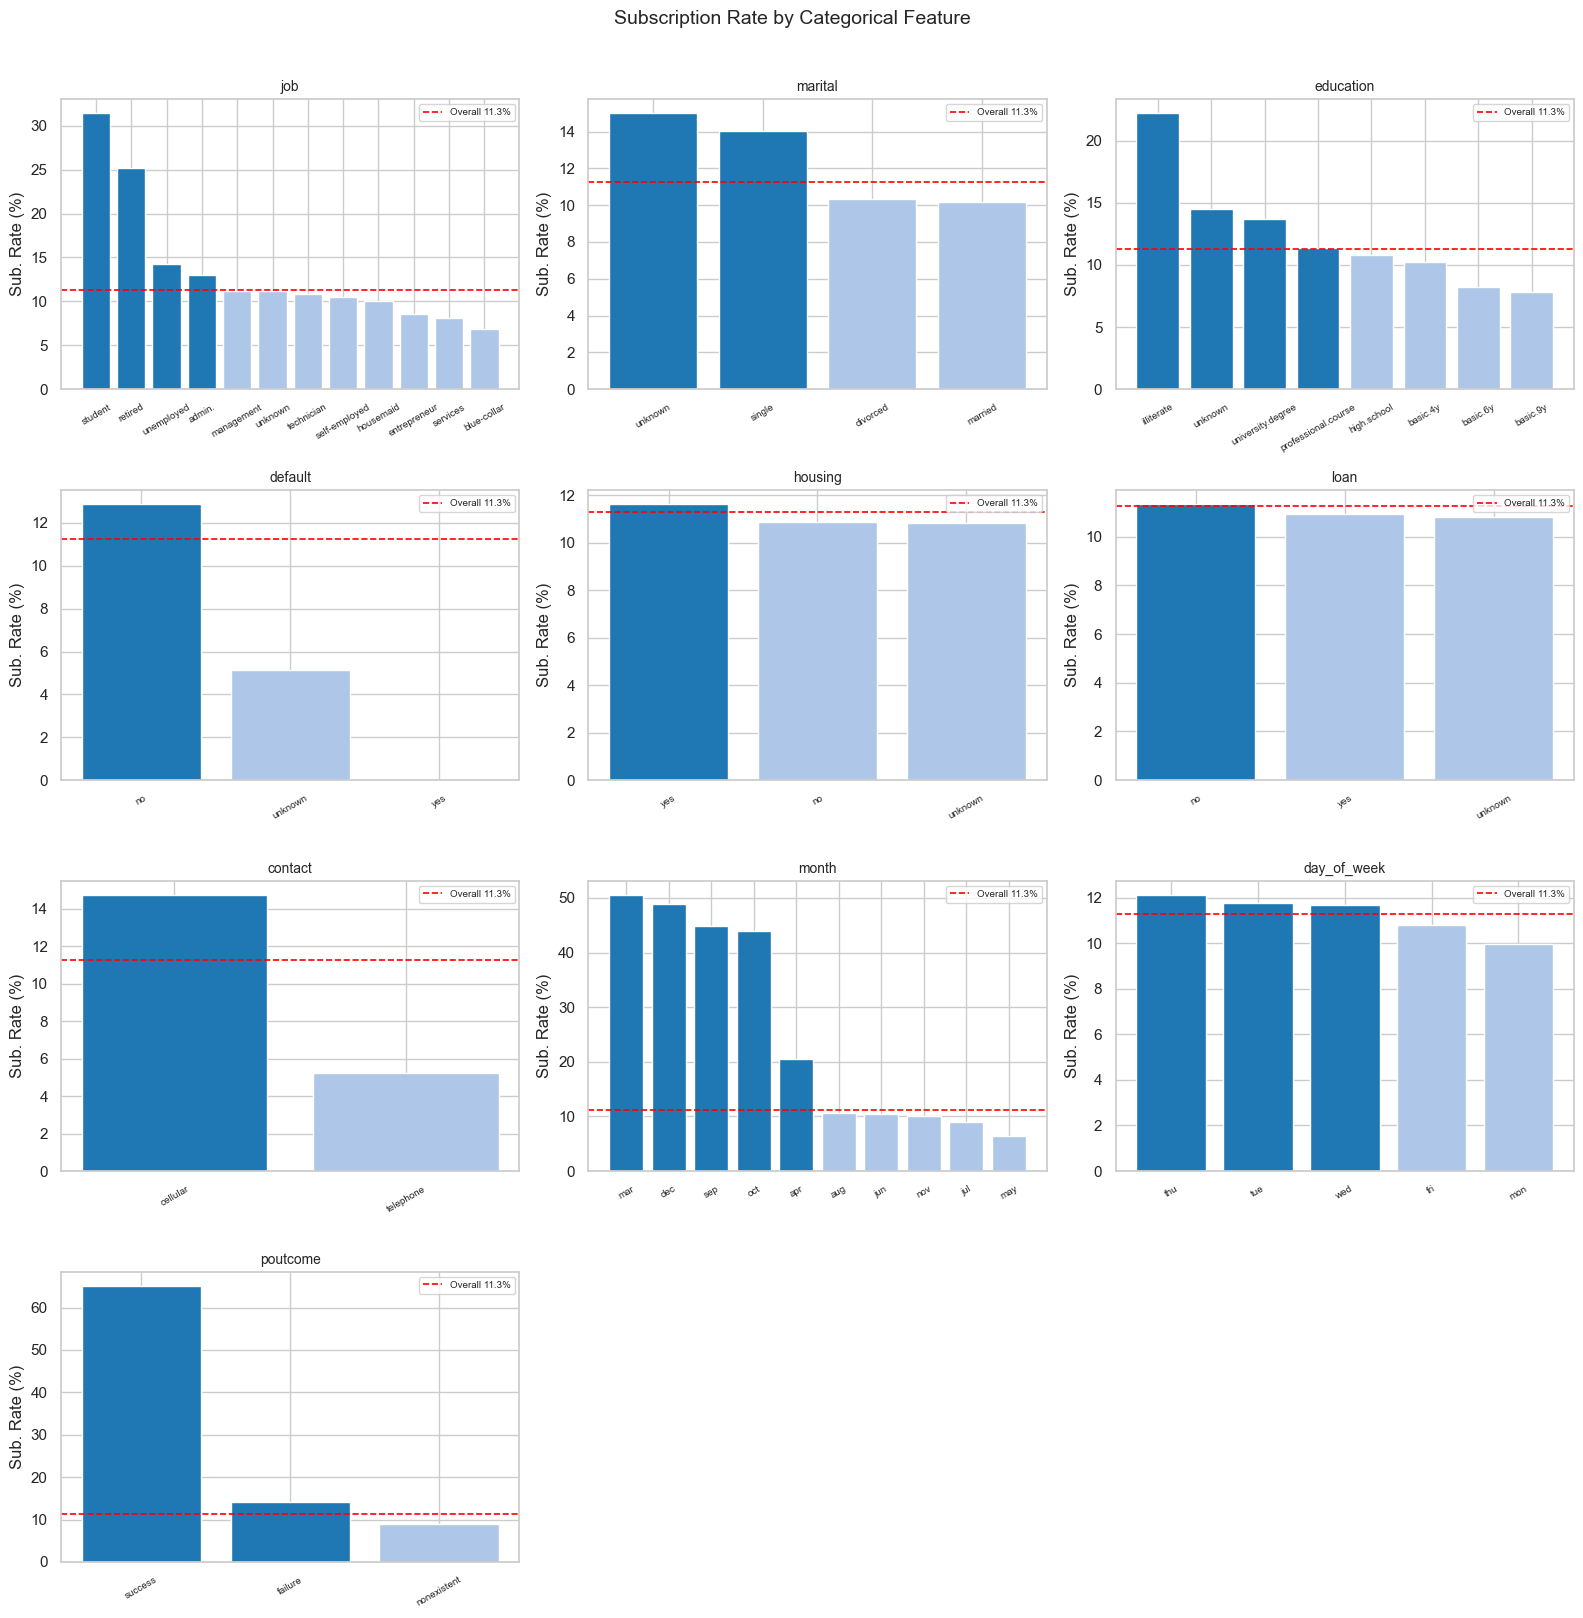

In [10]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    rate = df.groupby(col, observed=True)[TARGET_COL].mean().sort_values(ascending=False)
    colors = ["#1f77b4" if v > df[TARGET_COL].mean() else "#aec7e8" for v in rate.values]
    axes[i].bar(rate.index, rate.values * 100, color=colors)
    axes[i].axhline(df[TARGET_COL].mean() * 100, color="red", linestyle="--", lw=1.2,
                    label=f"Overall {df[TARGET_COL].mean()*100:.1f}%")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Sub. Rate (%)")
    axes[i].tick_params(axis="x", rotation=30, labelsize=7)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Subscription Rate by Categorical Feature", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()